# Suma de flujos diferenciales

Versión alternativa del notebook original. Aquí se suma primero el flujo diferencial
$dhi / dE dos	heta$ de todos los mesones en una malla común de energía para cada masa,
y después se integra sobre energía.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.integrate import simpson

cwd = '/home/lurishi/Escritorio/HeavenlyMCP/'
path_to_style = cwd + '/Figures'

plt.rcParams.update({'font.family': 'serif'})

In [2]:
path = cwd + '/Data/MCP_flux/MCP_flux'
df_pi0_ = pd.read_csv('/home/lurishi/Escritorio/HeavenlyMCP/Data/MCP_flux/MCP_FROM_PI0_SURFACE.csv')
df_eta_ = pd.read_csv(path + '/MCP_FROM_ETA_SURFACE.csv')
df_omega_ = pd.read_csv(path + '/MCP_FROM_OMEGA_SURFACE.csv')
df_rho_ = pd.read_csv(path + '/MCP_FROM_RHO_SURFACE.csv')
df_phi_ = pd.read_csv(path + '/MCP_FROM_PHI_SURFACE.csv')
df_jpsi_ = pd.read_csv(path + '/MCP_FROM_JPSI_SURFACE.csv')

In [3]:
eps2 = 1e-4

dfs = [
    df_pi0_[df_pi0_['cosTh'] == 1.0][df_pi0_['eps2'] == eps2],
    df_eta_[df_eta_['cosTh'] == 1.0][df_eta_['eps2'] == eps2],
    df_omega_[df_omega_['cosTh'] == 1.0][df_omega_['eps2'] == eps2],
    df_rho_[df_rho_['cosTh'] == 1.0][df_rho_['eps2'] == eps2],
    df_phi_[df_phi_['cosTh'] == 1.0][df_phi_['eps2'] == eps2],
    df_jpsi_[df_jpsi_['cosTh'] == 1.0][df_jpsi_['eps2'] == eps2],
]

meson_names = ['pi0', 'eta', 'omega', 'rho', 'phi', 'jpsi']
masses = [df['m(GeV)'].unique() for df in dfs]

/tmp/ipykernel_63005/2063316145.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_pi0_[df_pi0_['cosTh'] == 1.0][df_pi0_['eps2'] == eps2],
/tmp/ipykernel_63005/2063316145.py:5: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_eta_[df_eta_['cosTh'] == 1.0][df_eta_['eps2'] == eps2],
/tmp/ipykernel_63005/2063316145.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_omega_[df_omega_['cosTh'] == 1.0][df_omega_['eps2'] == eps2],
/tmp/ipykernel_63005/2063316145.py:7: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_rho_[df_rho_['cosTh'] == 1.0][df_rho_['eps2'] == eps2],
/tmp/ipykernel_63005/2063316145.py:8: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_phi_[df_phi_['cosTh'] == 1.0][df_phi_['eps2'] == eps2],
/tmp/ipykernel_63005/2063316145.py:9: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_

In [7]:
def integrate_original_flux(df):
    mass_values = np.sort(df['m(GeV)'].unique())
    flux_values = np.zeros(len(mass_values))

    for idx, mass_value in enumerate(mass_values):
        energy = df['Energy (GeV)'][df['m(GeV)'] == mass_value].to_numpy()
        differential = df['dphi_dEdCth(1/GeV/s/cm2)'][df['m(GeV)'] == mass_value].to_numpy()
        order = np.argsort(energy)
        flux_values[idx] = simpson(differential[order], energy[order]) / 2 * np.pi

    return mass_values, flux_values

def integrate_summed_differential_flux(dfs):
    all_masses = np.unique(np.concatenate([df['m(GeV)'].unique() for df in dfs]))
    summed_flux = np.zeros(len(all_masses))

    for idx, mass_value in enumerate(all_masses):
        energy_grids = []
        differential_curves = []

        for df in dfs:
            subset = df[df['m(GeV)'] == mass_value]
            if subset.empty:
                continue

            energy = subset['Energy (GeV)'].to_numpy()
            differential = subset['dphi_dEdCth(1/GeV/s/cm2)'].to_numpy()
            order = np.argsort(energy)
            energy_grids.append(energy[order])
            differential_curves.append(differential[order])

        if not energy_grids:
            continue

        common_energy = np.unique(np.concatenate(energy_grids))
        total_differential = np.zeros_like(common_energy, dtype=float)

        for energy, differential in zip(energy_grids, differential_curves):
            total_differential += np.interp(common_energy, energy, differential, left=0.0, right=0.0)

        summed_flux[idx] = simpson(total_differential, common_energy) / 2 * np.pi

    return all_masses, summed_flux

original_curves = [integrate_original_flux(df) for df in dfs]
summed_mass, summed_flux = integrate_summed_differential_flux(dfs)

common_mass = np.logspace(np.log10(summed_mass[0]), np.log10(summed_mass[-1]), 100)
original_total = np.zeros_like(common_mass)

for mass_values, flux_values, name in zip((c[0] for c in original_curves), (c[1] for c in original_curves), meson_names):
    mass_sorted_idx = np.argsort(mass_values)
    mass_sorted = np.asarray(mass_values)[mass_sorted_idx]
    flux_sorted = np.asarray(flux_values)[mass_sorted_idx]
    unique_mask = np.concatenate(([True], np.diff(mass_sorted) != 0))
    mass_unique = mass_sorted[unique_mask]
    flux_unique = flux_sorted[unique_mask]
    original_total += np.interp(common_mass, mass_unique, flux_unique, left=0.0, right=0.0)

summed_flux_interp = np.interp(common_mass, summed_mass, summed_flux, left=0.0, right=0.0)

print('Mass points in summed-differential version:', len(summed_mass))
print('Original total head:', original_total[:5])
print('Summed differential total head:', summed_flux_interp[:5])

Mass points in summed-differential version: 84
Original total head: [1.71170416e-07 1.64371842e-07 1.57307651e-07 1.50434241e-07
 1.43614393e-07]
Summed differential total head: [1.76393993e-07 1.55926031e-07 1.36561871e-07 1.30022454e-07
 1.23553939e-07]


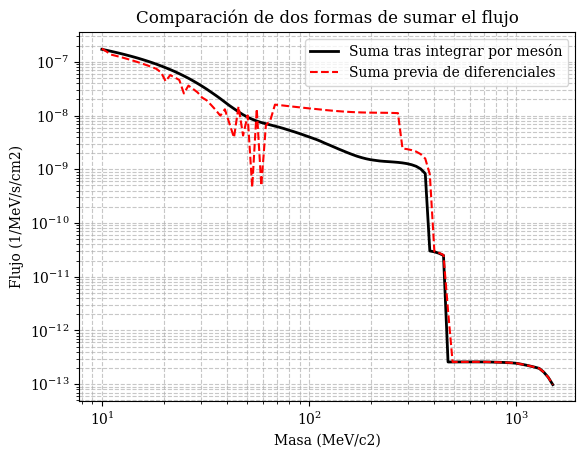

In [5]:
plt.plot(common_mass * 1000, original_total, label='Suma tras integrar por mesón', color='black', linewidth=2)
plt.plot(common_mass * 1000, summed_flux_interp, label='Suma previa de diferenciales', color='red', linestyle='--')
plt.xlabel('Masa (MeV/c2)')
plt.ylabel('Flujo (1/MeV/s/cm2)')
plt.title('Comparación de dos formas de sumar el flujo')
plt.xscale('log')
plt.yscale('log')
plt.grid(True, linestyle='--', which='both', alpha=0.7)
plt.legend()
plt.show()

In [6]:
ratio = summed_flux_interp / original_total
ratio

array([ 1.03051682,  0.94861765,  0.8681197 ,  0.86431423,  0.86031725,
        0.85603735,  0.85143946,  0.84672697,  0.84164298,  0.83613594,
        0.83026836,  0.82409343,  0.81734428,  0.75561896,  0.55957793,
        0.79031561,  0.77774843,  0.76350032,  0.47135071,  0.72913686,
        0.7069797 ,  0.68200761,  0.61394667,  0.61845237,  0.57707205,
        0.53232954,  0.48118179,  0.7341667 ,  0.46443537,  0.28969492,
        1.25259895,  0.40964787,  1.07859042,  0.05424506,  1.68660246,
        0.06657227,  0.92692966,  1.23336656,  2.51215177,  2.59015844,
        2.68148089,  2.78969522,  2.89774984,  3.02410043,  3.16243829,
        3.31820555,  3.48616281,  3.66564511,  3.88435475,  4.15633848,
        4.42494502,  4.73072185,  5.06470715,  5.41281384,  5.78740941,
        6.17650156,  6.56386238,  6.91962148,  7.24124396,  7.51672546,
        7.71098239,  7.90214758,  8.02449222,  8.11082043,  8.18225593,
        8.25177712,  1.85435736,  1.86239423,  1.87002697,  1.87